In [11]:
#Read the datasets
import pandas as pd

df1 = pd.read_csv("../../Data/atlas_vivli_2004_2024.csv")

df2 = pd.read_excel(
    "../../Data/Omadacycline_2015 to 2025_Surveillance_data.xlsx",
    engine="openpyxl"
)


/var/folders/vg/_pmbbnc53ld2tlj9zby7j6th0000gn/T/ipykernel_71810/611221873.py:4: DtypeWarning: Columns (0: State, 1: Ampicillin sulbactam, 2: Ampicillin sulbactam_I, 3: Azithromycin, 4: Aztreonam, 5: Aztreonam avibactam, 6: Aztreonam_I, 7: Cefiderocol, 8: Cefiderocol_I, 9: Cefixime, 10: Cefixime_I, 11: Cefoperazone sulbactam, 12: Cefoxitin, 13: Cefoxitin_I, 14: Cefpodoxime, 15: Cefpodoxime_I, 16: Ceftaroline, 17: Ceftaroline_I, 18: Ceftazidime avibactam, 19: Ceftazidime avibactam_I, 20: Ceftibuten, 21: Ceftibuten_I, 22: Ceftolozane tazobactam, 23: Ceftolozane tazobactam_I, 24: Ciprofloxacin, 25: Ciprofloxacin_I, 26: Clarithromycin, 27: Clarithromycin_I, 28: Colistin, 29: Colistin_I, 30: Daptomycin, 31: Daptomycin_I, 32: Doripenem, 33: Doripenem_I, 34: Ertapenem, 35: Ertapenem_I, 36: Gatifloxacin, 37: Gentamicin, 38: Gentamicin_I, 39: Imipenem, 40: Imipenem_I, 41: Meropenem vaborbactam, 42: Meropenem vaborbactam_I, 43: Metronidazole, 44: Metronidazole_I, 45: Minocycline, 46: Minocycline

In [12]:
#Create Organism-level Summary Tables
gene_cols = [
    "IMP","KPC","NDM","OXA",
    "PER","SHV","SPM","TEM",
    "VEB","VIM"
]

organism_gene_burden = (
    df1.groupby("Species")[gene_cols]
       .apply(lambda x: x.notna().mean()*100)
)

organism_gene_burden["Gene_Burden"] = (
    organism_gene_burden.mean(axis=1)
)

organism_gene_burden.head()

,IMP,KPC,NDM,OXA,PER,SHV,SPM,TEM,VEB,VIM,Gene_Burden
Species,,,,,,,,,,,
Achromobacter insolitus,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
Achromobacter xylosoxidans,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
Acidaminococcus fermentans,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
Acinetobacter alcaligenes,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
Acinetobacter anitratus,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [13]:
# define overall gene prevalence (percentage of non-missing per gene)
gene_prevalence = df1[gene_cols].notna().mean() * 100
gene_prevalence

IMP    0.042228
KPC    0.526817
NDM    0.498631
OXA    0.564694
PER    0.019285
SHV    2.762943
SPM    0.000494
TEM    2.880431
VEB    0.062008
VIM    0.218757
dtype: float64

In [14]:
organism_gene_burden.sort_values(
    "Gene_Burden",
    ascending=False
).head(20)

,IMP,KPC,NDM,OXA,PER,SHV,SPM,TEM,VEB,VIM,Gene_Burden
Species,,,,,,,,,,,
Klebsiella pneumoniae,0.035532,4.157238,2.794868,3.439119,0.011221,24.902287,0.0,17.714548,0.064519,0.236568,5.335590
Klebsiella spp,0.000000,3.496503,5.361305,5.594406,0.000000,10.256410,0.0,7.925408,0.000000,0.000000,3.263403
Providencia spp,0.000000,0.000000,9.395973,0.671141,2.684564,0.000000,0.0,2.013423,4.026846,0.000000,1.879195
Providencia rettgeri,0.097418,0.000000,5.845105,2.045787,0.438383,0.194837,0.0,4.091573,1.850950,0.146128,1.471018
Providencia stuartii,0.043234,0.000000,4.971898,0.518807,0.129702,0.951146,0.0,2.810203,1.815824,1.642888,1.288370
Enterobacter hormaechi,0.245165,0.599292,4.848815,0.626532,0.000000,0.844457,0.0,4.086080,0.299646,1.035140,1.258513
Proteus mirabilis,0.018423,0.036846,0.607959,0.138172,0.119749,0.221076,0.0,5.876934,1.133014,0.147384,0.829956
Citrobacter farmeri,0.000000,0.980392,0.980392,0.000000,0.000000,1.960784,0.0,0.980392,0.000000,2.941176,0.784314
Escherichia coli,0.003972,0.136640,0.535439,0.235943,0.002383,0.439314,0.0,6.157549,0.007150,0.017477,0.753587


In [15]:
species_counts = df1["Species"].value_counts()

species_counts.head()
# Species with at least 50 isolates
common_species = species_counts[
    species_counts >= 50
].index

#Filter
organism_gene_burden_filtered = (
    organism_gene_burden.loc[common_species]
)
print(organism_gene_burden_filtered)

#Rank 
organism_gene_burden_filtered.sort_values(
    "Gene_Burden",
    ascending=False
).head(20)

                                IMP       KPC       NDM       OXA       PER  \
Species                                                                       
Staphylococcus aureus      0.000000  0.000000  0.000000  0.000000  0.000000   
Escherichia coli           0.003972  0.136640  0.535439  0.235943  0.002383   
Pseudomonas aeruginosa     0.218467  0.177882  0.248690  0.000000  0.117437   
Klebsiella pneumoniae      0.035532  4.157238  2.794868  3.439119  0.011221   
Streptococcus pneumoniae   0.000000  0.000000  0.000000  0.000000  0.000000   
...                             ...       ...       ...       ...       ...   
Clostridium septicum       0.000000  0.000000  0.000000  0.000000  0.000000   
Peptoniphilus spp          0.000000  0.000000  0.000000  0.000000  0.000000   
Acinetobacter courvalinii  0.000000  0.000000  0.000000  0.000000  0.000000   
Clostridium hathewayi      0.000000  0.000000  0.000000  0.000000  0.000000   
Klebsiella ozaenae         0.000000  0.000000  0.000

,IMP,KPC,NDM,OXA,PER,SHV,SPM,TEM,VEB,VIM,Gene_Burden
Species,,,,,,,,,,,
Klebsiella pneumoniae,0.035532,4.157238,2.794868,3.439119,0.011221,24.902287,0.0,17.714548,0.064519,0.236568,5.335590
Klebsiella spp,0.000000,3.496503,5.361305,5.594406,0.000000,10.256410,0.0,7.925408,0.000000,0.000000,3.263403
Providencia spp,0.000000,0.000000,9.395973,0.671141,2.684564,0.000000,0.0,2.013423,4.026846,0.000000,1.879195
Providencia rettgeri,0.097418,0.000000,5.845105,2.045787,0.438383,0.194837,0.0,4.091573,1.850950,0.146128,1.471018
Providencia stuartii,0.043234,0.000000,4.971898,0.518807,0.129702,0.951146,0.0,2.810203,1.815824,1.642888,1.288370
Enterobacter hormaechi,0.245165,0.599292,4.848815,0.626532,0.000000,0.844457,0.0,4.086080,0.299646,1.035140,1.258513
Proteus mirabilis,0.018423,0.036846,0.607959,0.138172,0.119749,0.221076,0.0,5.876934,1.133014,0.147384,0.829956
Citrobacter farmeri,0.000000,0.980392,0.980392,0.000000,0.000000,1.960784,0.0,0.980392,0.000000,2.941176,0.784314
Escherichia coli,0.003972,0.136640,0.535439,0.235943,0.002383,0.439314,0.0,6.157549,0.007150,0.017477,0.753587


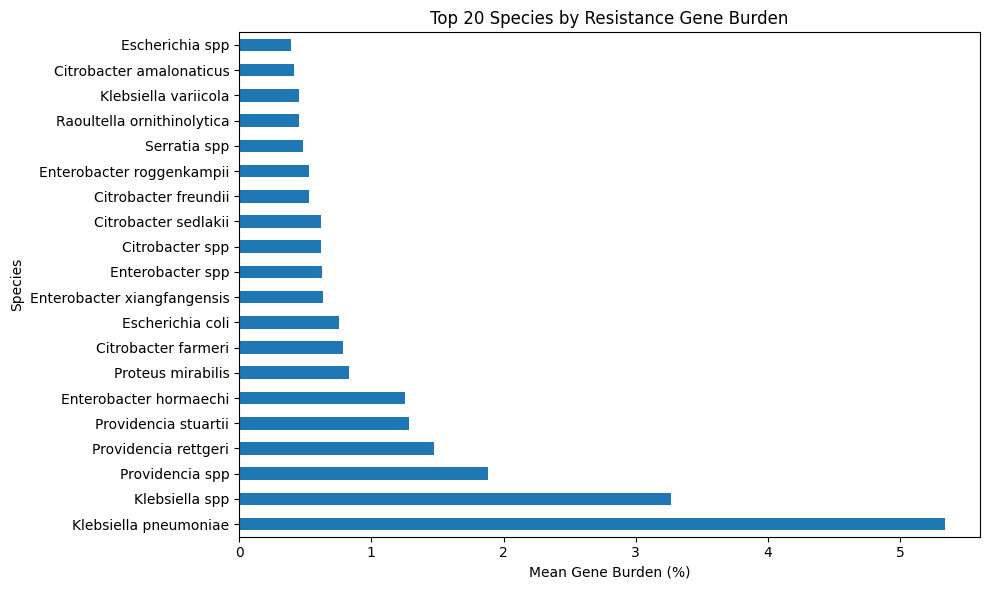

In [16]:
# Visualize top 20 species
top20_species = (
    organism_gene_burden_filtered
    .sort_values("Gene_Burden", ascending=False)
    .head(20)
)

import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))

top20_species["Gene_Burden"].plot(
    kind="barh"
)

plt.title(
    "Top 20 Species by Resistance Gene Burden"
)

plt.xlabel(
    "Mean Gene Burden (%)"
)

plt.tight_layout()

plt.show()

In [17]:
for gene in gene_cols:
    print(
        gene,
        df1[gene].notna().sum()
    )
# Global AMR Prevalance Ranking: TEM > SHV > OXA > KPC > NDM > VIM > VEB > IMP > PER > SPM
#TEM and SHV remain the dominant global β-lactam resistance genes.
#NDM and KPC are less common overall but are clinically more concerning because they confer carbapenem resistance.
#SPM, PER, and IMP are relatively rare.

IMP 427
KPC 5327
NDM 5042
OXA 5710
PER 195
SHV 27938
SPM 5
TEM 29126
VEB 627
VIM 2212


In [18]:
species_burden = (
    df1.groupby("Species")[gene_cols]
       .apply(lambda x: x.notna().mean()*100)
       .mean(axis=1)
       .sort_values(ascending=False)
)

species_burden.head(20)
species_burden.to_csv("../../outputs/tables/species_burden.csv")


In [19]:
priority_score.sort_values(
    ascending=False
).head(20).round(6)
df1["Priority_Present"] = (
    df1["Priority_Burden"] > 0
).astype(int)
#Species level prevalence
species_priority = (
    df1.groupby("Species")["Priority_Present"]
       .mean()
       .mul(100)
       .sort_values(ascending=False)
)

species_priority.head(20)

NameError: name 'priority_score' is not defined

In [ ]:
genes_binary[["NDM","KPC","OXA"]].sum()

NDM    5042
KPC    5327
OXA    5710
dtype: int64

In [ ]:
print(df1["NDM"].dropna().head(20))

148704    NDM-1
239920    NDM-1
241975    NDM-1
241998    NDM-1
249362    NDM-1
249574    NDM-1
249600    NDM-1
249940    NDM-1
249952    NDM-1
249959    NDM-1
251795    NDM-1
251798    NDM-1
251800    NDM-1
251806    NDM-1
251836    NDM-1
251840    NDM-1
251844    NDM-1
251874    NDM-1
253113    NDM-1
253974    NDM-1
Name: NDM, dtype: str


In [ ]:
priority_genes = ["NDM", "KPC", "OXA"]

df1["Priority_Burden"] = (
    genes_binary[priority_genes]
    .sum(axis=1)
)

print(df1["Priority_Burden"].value_counts())

#996,461 isolates have none of the priority genes (NDM, KPC, OXA).
#13,337 isolates have one priority gene.
#1,368 isolates have two priority genes.
#2 isolates have all three priority genes.


Priority_Burden
0    996461
1     13337
2      1368
3         2
Name: count, dtype: int64


In [ ]:
genes_binary = df1[gene_cols].notna().astype(int)

print(
    genes_binary[
        ["NDM","KPC","OXA"]
    ].sum()
)

NDM    5042
KPC    5327
OXA    5710
dtype: int64


In [ ]:
#Species risk tablle
species_risk = pd.DataFrame()

# ensure AMR_Burden exists before grouping
df1["AMR_Burden"] = genes_binary.sum(axis=1)

species_risk["ARG_Burden"] = (
    df1.groupby("Species")["AMR_Burden"]
       .mean()
)

species_risk["Priority_Prevalence"] = (
    df1.groupby("Species")["Priority_Present"]
       .mean() * 100
)

In [ ]:
#Clinical risk table
clinical_risk = pd.DataFrame()

sir_df = df2.copy()
antibiotic_cols = [
    col for col in sir_df.columns
    if col not in [
        "Collection \nNumber",
        "Study",
        "Year",
        "Organism",
        "Continent",
        "Country",
        "US Census Division",
        "Nosocomial",
        "Age",
        "Gender",
        "Medical Service",
        "Infection Source",
        "Infection Type",
        "Source of Bloodstream infection",
        "Specimen Type",
        "Ventilator-Associated Pneumonia",
        "Intensive\nCare Unit\n(ICU)",
        "Cystic Fibrosis (CF)\nPatient",
    ]
]

clinical_risk["Clinical_Resistance"] = (
    sir_df.groupby("Organism")[antibiotic_cols]
          .apply(lambda x: (x == "R").mean() * 100)
          .mean(axis=1)
)

clinical_risk["Omadacycline_S"] = (
    sir_df.groupby("Organism")["Omadacycline"]
          .apply(lambda x: (x=="S").mean()*100)
)

In [ ]:
#Standarize names
species_risk.index = (
    species_risk.index
    .str.lower()
    .str.strip()
)

clinical_risk.index = (
    clinical_risk.index
    .str.lower()
    .str.strip()
)

In [ ]:
#Merge
integrated = pd.merge(
    species_risk,
    clinical_risk,
    left_index=True,
    right_index=True,
    how="inner"
)

integrated.head()

,ARG_Burden,Priority_Prevalence,Clinical_Resistance,Omadacycline_S
Species,,,,
acinetobacter baumannii,0.030792,3.068139,0.0,0.0
acinetobacter beijerinckii,0.000000,0.000000,0.0,0.0
acinetobacter bereziniae,0.000000,0.000000,0.0,0.0
acinetobacter courvalinii,0.000000,0.000000,0.0,0.0
acinetobacter dispersus,0.000000,0.000000,0.0,0.0


In [ ]:
#Calculate risk score
integrated["Risk_Score"] = (
      0.50 * integrated["Priority_Prevalence"]
    + 0.30 * integrated["Clinical_Resistance"]
    + 0.20 * integrated["ARG_Burden"]
)
#Normalize
integrated["Risk_Score"] = (
    integrated["Risk_Score"]
    /
    integrated["Risk_Score"].max()
) * 100

In [ ]:
integrated.loc[
    "acinetobacter baumannii"
]

ARG_Burden              0.030792
Priority_Prevalence     3.068139
Clinical_Resistance     0.000000
Omadacycline_S          0.000000
Risk_Score             32.478989
Protection_Score      -32.478989
Name: acinetobacter baumannii, dtype: float64

In [ ]:
integrated.describe()
integrated[
    integrated["Risk_Score"] > 0
].shape

(26, 6)

In [ ]:
print(clinical_risk.index[:20])

Index(['acinetobacter baumannii',
       'acinetobacter baumannii-calcoaceticus species complex',
       'acinetobacter beijerinckii', 'acinetobacter bereziniae',
       'acinetobacter courvalinii', 'acinetobacter dispersus',
       'acinetobacter guillouiae', 'acinetobacter gyllenbergii',
       'acinetobacter haemolyticus', 'acinetobacter johnsonii',
       'acinetobacter junii', 'acinetobacter lwoffii',
       'acinetobacter nosocomialis', 'acinetobacter proteolyticus',
       'acinetobacter radioresistens', 'acinetobacter schindleri',
       'acinetobacter soli', 'acinetobacter ursingii',
       'acinetobacter variabilis', 'acinetobacter vivianii'],
      dtype='str', name='Organism')


In [ ]:
species1 = set(species_risk.index)
species2 = set(clinical_risk.index)

overlap = species1.intersection(species2)

print("Dataset1 species:", len(species1))
print("Dataset2 species:", len(species2))
print("Overlap:", len(overlap))

print(list(overlap)[:20])

Dataset1 species: 400
Dataset2 species: 165
Overlap: 109
['staphylococcus pettenkoferi', 'enterococcus mundtii', 'streptococcus gordonii', 'enterobacter cloacae', 'haemophilus parainfluenzae', 'pantoea agglomerans', 'moraxella osloensis', 'serratia fonticola', 'streptococcus agalactiae', 'enterococcus faecium', 'staphylococcus aureus', 'staphylococcus lugdunensis', 'providencia rettgeri', 'raoultella planticola', 'acinetobacter baumannii', 'proteus hauseri', 'acinetobacter ursingii', 'proteus vulgaris', 'escherichia fergusonii', 'staphylococcus haemolyticus']


In [ ]:
species_risk.index = (
    species_risk.index
    .str.lower()
    .str.strip()
)

clinical_risk.index = (
    clinical_risk.index
    .str.lower()
    .str.strip()
)
print(clinical_risk.index)
print(species_risk.index)


Index(['acinetobacter baumannii',
       'acinetobacter baumannii-calcoaceticus species complex',
       'acinetobacter beijerinckii', 'acinetobacter bereziniae',
       'acinetobacter courvalinii', 'acinetobacter dispersus',
       'acinetobacter guillouiae', 'acinetobacter gyllenbergii',
       'acinetobacter haemolyticus', 'acinetobacter johnsonii',
       ...
       'unspeciated enterobacter', 'unspeciated erwinia',
       'unspeciated pantoea', 'unspeciated providencia',
       'unspeciated raoultella', 'unspeciated salmonella',
       'unspeciated serratia', 'unspeciated staphylococcus',
       'unspeciated coagulase-negative staphylococci',
       'yersinia enterocolitica'],
      dtype='str', name='Organism', length=165)
Index(['achromobacter insolitus', 'achromobacter xylosoxidans',
       'acidaminococcus fermentans', 'acinetobacter alcaligenes',
       'acinetobacter anitratus', 'acinetobacter baumannii',
       'acinetobacter baylyi', 'acinetobacter beijerinckii',
       'a

In [ ]:
integrated["Treatment_Gap"] = (
    integrated["Clinical_Resistance"]
    -
    integrated["Omadacycline_S"]
)
print(integrated["Treatment_Gap"])

Species
acinetobacter baumannii        0.0
acinetobacter beijerinckii     0.0
acinetobacter bereziniae       0.0
acinetobacter courvalinii      0.0
acinetobacter dispersus        0.0
                              ... 
streptococcus parasanguinis    0.0
streptococcus pneumoniae       0.0
streptococcus pyogenes         0.0
streptococcus salivarius       0.0
streptococcus sanguinis        0.0
Name: Treatment_Gap, Length: 109, dtype: float64


In [26]:
#Integrated Threat Ranking
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()

# Ensure species_priority exists before using it
if "species_priority" not in globals():
    genes_binary = df1[gene_cols].notna().astype(int)

    priority_genes = ["NDM", "KPC", "OXA"]
    df1["Priority_Burden"] = (
        genes_binary[priority_genes]
        .sum(axis=1)
    )
    df1["Priority_Present"] = (
        df1["Priority_Burden"] > 0
    ).astype(int)

    species_priority = (
        df1.groupby("Species")["Priority_Present"]
           .mean()
           .mul(100)
           .sort_values(ascending=False)
    )

integrated_metrics = pd.DataFrame()

integrated_metrics["Gene_Burden"] = species_burden
integrated_metrics["Priority_Prevalence"] = species_priority.reindex(
    integrated_metrics.index
)

integrated_metrics = integrated_metrics.fillna(0)

integrated_metrics[[
    "Gene_Burden_N",
    "Priority_Prevalence_N"
]] = scaler.fit_transform(
    integrated_metrics[[
        "Gene_Burden",
        "Priority_Prevalence"
    ]]
)
print(integrated_metrics)


                        Gene_Burden  Priority_Prevalence  Gene_Burden_N  \
Species                                                                   
Klebsiella pneumoniae      5.335590             9.271034       1.000000   
Klebsiella spp             3.263403            11.655012       0.611629   
Providencia spp            1.879195            10.067114       0.352200   
Providencia rettgeri       1.471018             6.380906       0.275699   
Providencia stuartii       1.288370             5.317769       0.241467   
...                             ...                  ...            ...   
Clostridium sphenoides     0.000000             0.000000       0.000000   
Clostridium sordellii      0.000000             0.000000       0.000000   
Clostridium septicum       0.000000             0.000000       0.000000   
Clostridium scindens       0.000000             0.000000       0.000000   
Veillonella parvula        0.000000             0.000000       0.000000   

                        

In [ ]:
from sklearn.preprocessing import MinMaxScaler
import pandas as pd

scaler = MinMaxScaler()

#  Binary gene matrix
genes_binary = df1[gene_cols].notna().astype(int)

#  priority genes
priority_genes = ["NDM", "KPC", "OXA"]

# Step 3: burden per sample (row-level)
df1["Priority_Burden"] = genes_binary[priority_genes].sum(axis=1)

df1["Priority_Present"] = (df1["Priority_Burden"] > 0).astype(int)

#  species-level aggregation
species_priority = (
    df1.groupby("Species")["Priority_Present"]
    .mean()
    .mul(100)
    .sort_values(ascending=False)
)


#  integrate
integrated_metrics = pd.DataFrame()
integrated_metrics["Gene_Burden"] = species_burden
integrated_metrics["Priority_Prevalence"] = species_priority.reindex(integrated_metrics.index)

integrated_metrics = integrated_metrics.fillna(0)

# Step 6: normalize
integrated_metrics[["Gene_Burden_N", "Priority_Prevalence_N"]] = scaler.fit_transform(
    integrated_metrics[["Gene_Burden", "Priority_Prevalence"]]
)

print(integrated_metrics)
#Klebsiella pneumoniae = 5.33 → very high genetic resistance complexity
#Providencia spp = 1.87 → moderate burden
#Clostridium spp = 0 → no detected ARGs in dataset


                        Gene_Burden  Priority_Prevalence  Gene_Burden_N  \
Species                                                                   
Klebsiella pneumoniae      5.335590             9.271034       1.000000   
Klebsiella spp             3.263403            11.655012       0.611629   
Providencia spp            1.879195            10.067114       0.352200   
Providencia rettgeri       1.471018             6.380906       0.275699   
Providencia stuartii       1.288370             5.317769       0.241467   
...                             ...                  ...            ...   
Clostridium sphenoides     0.000000             0.000000       0.000000   
Clostridium sordellii      0.000000             0.000000       0.000000   
Clostridium septicum       0.000000             0.000000       0.000000   
Clostridium scindens       0.000000             0.000000       0.000000   
Veillonella parvula        0.000000             0.000000       0.000000   

                        